In [19]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%autosave 0
    
import logging
logging.basicConfig(format='%(asctime)s %(levelname)s:%(message)s', level=logging.DEBUG, datefmt='%I:%M:%S')

import os
import sys
import numpy as np
import pandas as pd
import sdata
import uuid
import time
from sdata import Data
from sdata.iolib.vault import FileSystemVault
print("sdata v{}".format(sdata.__version__))
from sdata.contrib.simple_graph_db import Database

11:30:48 DEBUG:Loaded backend module://ipykernel.pylab.backend_inline version unknown.


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Autosave disabled
sdata v0.17.0


In [20]:
import pygraphviz as pgv
from IPython.display import Image

def draw(dot):
    return Image(pgv.AGraph(dot).draw(format='png', prog='dot'))

In [21]:
vaultrootpath = "/tmp/sdatavaultgraphclass/"
import shutil
shutil.rmtree(vaultrootpath, ignore_errors=True)

In [22]:
vault = FileSystemVault(vaultrootpath)


11:30:48 INFO:create/open vault '/tmp/sdatavaultgraphclass'
11:30:48 INFO:create/open vaultindex '/tmp/sdatavaultgraphclass/vaultindex.sqlite'
11:30:48 DEBUG:initialize db /tmp/sdatavaultgraphclass/vaultindex.sqlite


True


In [23]:
vault

(FileSystemVault:/tmp/sdatavaultgraphclass)

In [24]:
data = sdata.Data(name="otto", 
                  uuid=sdata.uuid_from_str("otto"), 
                  table=pd.DataFrame({"a":[1,2,3]}),
                  description="Hallo\nSpencer",
                  project="P1")
data.metadata.add("a", 1)
datac = data.copy()
datac.uuid = '2689e23926874382b10b95e0f1cd90eb'
data2 = sdata.Data(name="karl", 
                   uuid=sdata.uuid_from_str("karl"))
data, datac, data2

11:30:52 DEBUG:make copy of 21b83703d98e38a7be2e50e38326d0ce -> a9463daf7b3f4742934b213a38261bda


((Data 'otto':21b83703d98e38a7be2e50e38326d0ce),
 (Data 'otto':2689e23926874382b10b95e0f1cd90eb),
 (Data 'karl':df26fe1945b93a149ee710e8fa887b2e))

11:25:55 INFO:dump blob /tmp/sdatavaultgraphclass/objects/26/eb/
11:25:55 INFO:NumExpr defaulting to 8 threads.
/home/ingolf.lepenies/anaconda3/envs/sfem3/lib/python3.7/site-packages/ipykernel_launcher.py:1: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['name', 'value', 'dtype', 'unit', 'description', 'label'], dtype='object')]

  """Entry point for launching an IPython kernel.
11:25:55 DEBUG:add '2689e23926874382b10b95e0f1cd90eb' to vault index


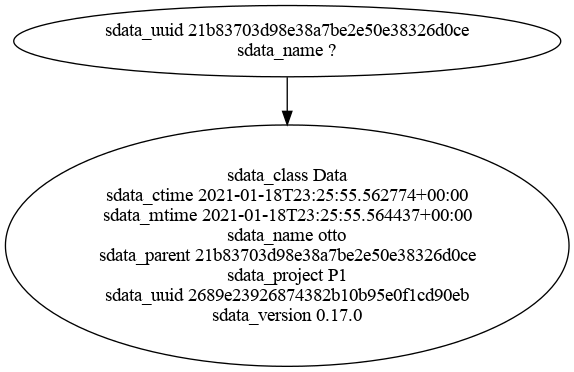

In [7]:
vault.dump_blob(datac)
dot_str = vault.index.db.get_dot(path=vault.index.db.get_all_node_ids())
draw(dot_str)

11:25:56 INFO:dump blob /tmp/sdatavaultgraphclass/objects/df/2e/
11:25:56 DEBUG:add 'df26fe1945b93a149ee710e8fa887b2e' to vault index


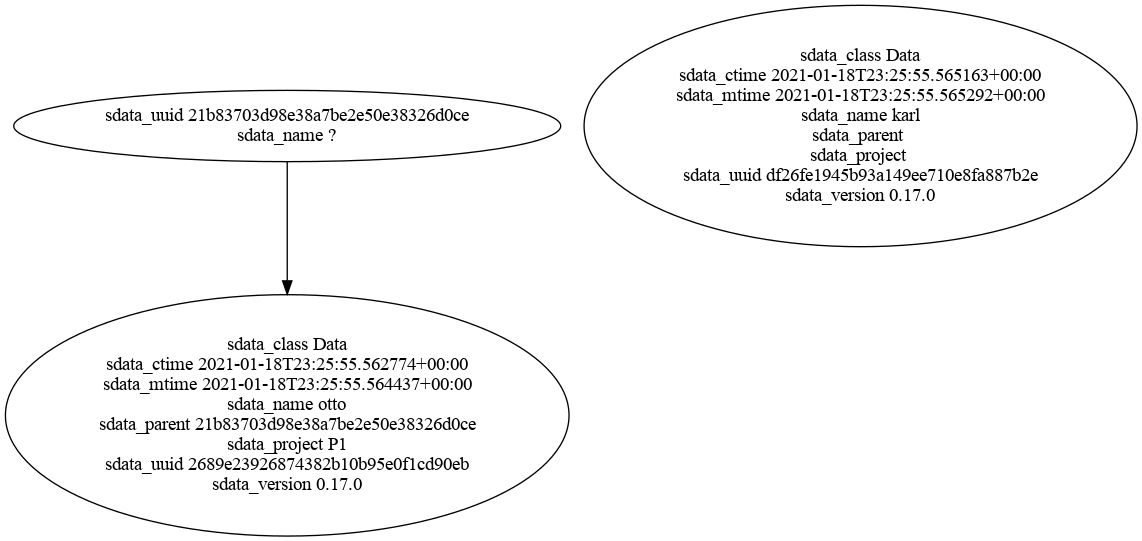

In [8]:
vault.dump_blob(data2)
dot_str = vault.index.db.get_dot(path=vault.index.db.get_all_node_ids())
draw(dot_str)

11:25:56 INFO:dump blob /tmp/sdatavaultgraphclass/objects/21/ce/
/home/ingolf.lepenies/anaconda3/envs/sfem3/lib/python3.7/site-packages/ipykernel_launcher.py:1: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['name', 'value', 'dtype', 'unit', 'description', 'label'], dtype='object')]

  """Entry point for launching an IPython kernel.
11:25:56 DEBUG:add '21b83703d98e38a7be2e50e38326d0ce' to vault index


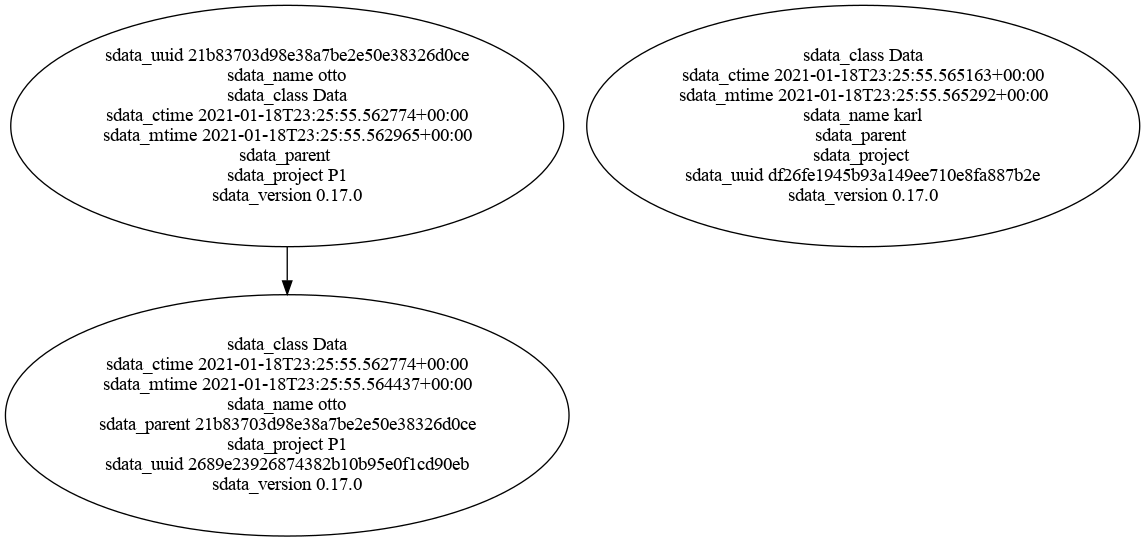

In [9]:
vault.dump_blob(data)
dot_str = vault.index.db.get_dot(path=vault.index.db.get_all_node_ids())
draw(dot_str)

In [10]:
vault.index.db.get_all_node_ids()

['2689e23926874382b10b95e0f1cd90eb',
 '21b83703d98e38a7be2e50e38326d0ce',
 'df26fe1945b93a149ee710e8fa887b2e']

In [11]:
vault.index.db.get_all_edges()

[('21b83703d98e38a7be2e50e38326d0ce',
  '2689e23926874382b10b95e0f1cd90eb',
  '{"con_type":"parent"}')]

! digraph {
"2689e23926874382b10b95e0f1cd90eb" [label="sdata_class Data\nsdata_ctime 2021-01-18T23:25:55.562774+00:00\nsdata_mtime 2021-01-18T23:25:55.564437+00:00\nsdata_name otto\nsdata_parent 21b83703d98e38a7be2e50e38326d0ce\nsdata_project P1\nsdata_uuid 2689e23926874382b10b95e0f1cd90eb\nsdata_version 0.17.0"];
"21b83703d98e38a7be2e50e38326d0ce" [label="sdata_uuid 21b83703d98e38a7be2e50e38326d0ce\nsdata_name otto\nsdata_class Data\nsdata_ctime 2021-01-18T23:25:55.562774+00:00\nsdata_mtime 2021-01-18T23:25:55.562965+00:00\nsdata_parent \nsdata_project P1\nsdata_version 0.17.0"];
"21b83703d98e38a7be2e50e38326d0ce" -> "2689e23926874382b10b95e0f1cd90eb" [label=""];
"df26fe1945b93a149ee710e8fa887b2e" [label="sdata_class Data\nsdata_ctime 2021-01-18T23:25:55.565163+00:00\nsdata_mtime 2021-01-18T23:25:55.565292+00:00\nsdata_name karl\nsdata_parent \nsdata_project \nsdata_uuid df26fe1945b93a149ee710e8fa887b2e\nsdata_version 0.17.0"];
}



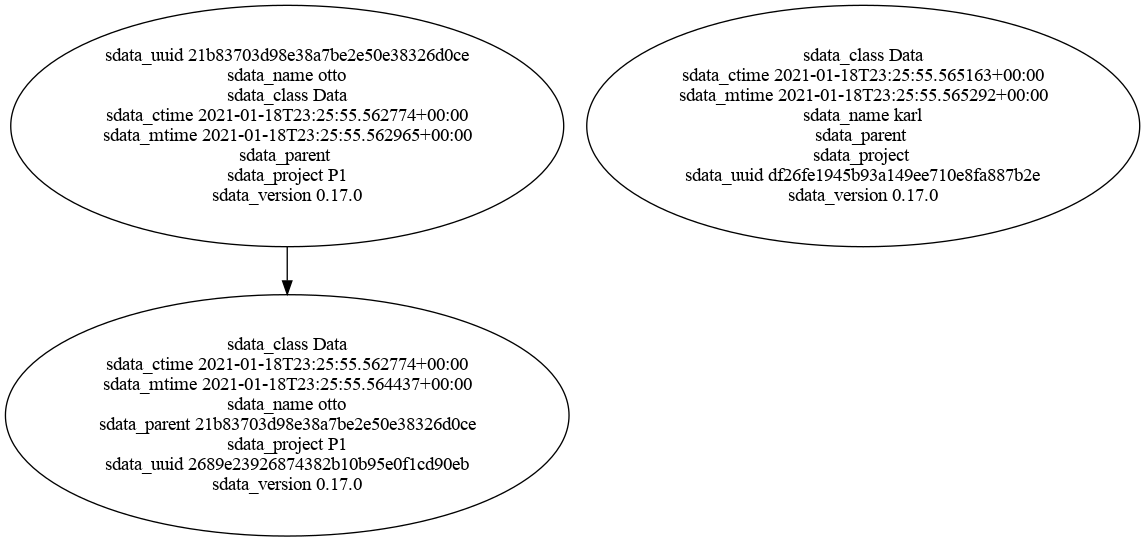

In [12]:
dot_str = vault.index.db.get_dot(path=vault.index.db.get_all_node_ids())
print("!", dot_str)
draw(dot_str)

In [13]:
vault.index.drop_db()

11:25:56 DEBUG:initialize db /tmp/sdatavaultgraphclass/vaultindex.sqlite


In [14]:
vault.index.db.find_neighbors(data.uuid)

[]

In [15]:
dot_str = vault.index.db.get_dot(path=vault.index.db.get_all_node_ids())
draw(dot_str)

11:25:56 DEBUG:initialize db /tmp/sdatavaultgraphclass/vaultindex.sqlite
11:25:56 INFO:get blob metadata /tmp/sdatavaultgraphclass/objects/26/eb/
11:25:56 DEBUG:add '2689e23926874382b10b95e0f1cd90eb' to vault index
11:25:56 INFO:get blob metadata /tmp/sdatavaultgraphclass/objects/21/ce/
11:25:56 DEBUG:add '21b83703d98e38a7be2e50e38326d0ce' to vault index
11:25:56 INFO:get blob metadata /tmp/sdatavaultgraphclass/objects/df/2e/
11:25:56 DEBUG:add 'df26fe1945b93a149ee710e8fa887b2e' to vault index


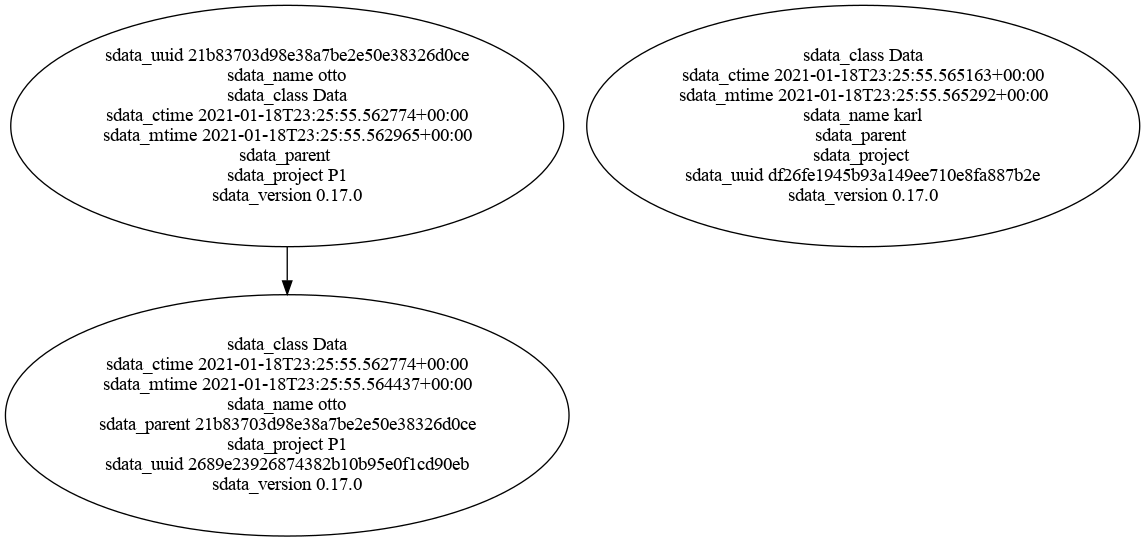

In [16]:
vault.reindex()
dot_str = vault.index.db.get_dot(path=vault.index.db.get_all_node_ids())
draw(dot_str)

In [17]:
vault.index.db.find_neighbors(datac.uuid)

[('21b83703d98e38a7be2e50e38326d0ce',
  '2689e23926874382b10b95e0f1cd90eb',
  '{"con_type":"parent"}')]

In [18]:
vault.index.df

,!sdata_class,!sdata_ctime,!sdata_mtime,!sdata_name,!sdata_parent,!sdata_project,!sdata_uuid,!sdata_version
id,,,,,,,,
2689e23926874382b10b95e0f1cd90eb,Data,2021-01-18T23:25:55.562774+00:00,2021-01-18T23:25:55.564437+00:00,otto,21b83703d98e38a7be2e50e38326d0ce,P1,2689e23926874382b10b95e0f1cd90eb,0.17.0
21b83703d98e38a7be2e50e38326d0ce,Data,2021-01-18T23:25:55.562774+00:00,2021-01-18T23:25:55.562965+00:00,otto,,P1,21b83703d98e38a7be2e50e38326d0ce,0.17.0
df26fe1945b93a149ee710e8fa887b2e,Data,2021-01-18T23:25:55.565163+00:00,2021-01-18T23:25:55.565292+00:00,karl,,,df26fe1945b93a149ee710e8fa887b2e,0.17.0


In [25]:
data.metadata.to_dict()

{'!sdata_class': {'name': '!sdata_class',
  'value': 'Data',
  'unit': '-',
  'dtype': 'str',
  'description': 'sdata class',
  'label': '',
  'required': False},
 '!sdata_ctime': {'name': '!sdata_ctime',
  'value': '2021-01-20T23:30:52.034151+00:00',
  'unit': '-',
  'dtype': 'str',
  'description': 'creation date',
  'label': '',
  'required': False},
 '!sdata_mtime': {'name': '!sdata_mtime',
  'value': '2021-01-20T23:30:52.036132+00:00',
  'unit': '-',
  'dtype': 'str',
  'description': 'modification date',
  'label': '',
  'required': False},
 '!sdata_name': {'name': '!sdata_name',
  'value': 'otto',
  'unit': '-',
  'dtype': 'str',
  'description': 'name of the data object',
  'label': '',
  'required': False},
 '!sdata_parent': {'name': '!sdata_parent',
  'value': '',
  'unit': '-',
  'dtype': 'str',
  'description': 'uuid of the parent sdata object',
  'label': '',
  'required': False},
 '!sdata_project': {'name': '!sdata_project',
  'value': 'P1',
  'unit': '-',
  'dtype': 'str